In [46]:
%reload_ext autoreload
%autoreload 2

In [47]:
from waymo_agent import *

In [48]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [49]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from kret_sandbox.VIS import dtt

#### Load ENV

In [50]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

In [51]:
envconfig = EnvConfig()
cfg = envconfig

In [53]:
env = RideShareEnv(cfg)
G = env.graph

Assigned lambda values to nodes. Total lambda: 2.2343 (target: 2.3460)


In [54]:
s, info = env.reset()

In [55]:
SupplyDemandDF.space_config(envconfig)["shape"]

(3,)

In [56]:
BASE_CLASS_ATTRS = set(vars(EnrichedDF).keys())
BASE_CLASS_ATTRS

{'__annotations__',
 '__doc__',
 '__module__',
 'calc_width',
 'cols_to_pass_to_model',
 'column_order',
 'default_vals',
 'f_valid',
 'from_obs_numpy',
 'generate_empty',
 'space_config',
 'target_dtypes',
 'to_obs_numpy',
 'to_training_df',
 'validate_dtypes'}

In [57]:
action = env.action_space.sample()

In [58]:
# obs, reward, terminated, truncated, info = env.step(action)

In [59]:
veh, req, rides = get_obvs_tuple(env)

In [60]:
from waymo_agent.data_classes.supply_demand_df import SupplyDemandDF


get_sd_ratio(cfg, req, veh)[0]

np.float64(1.0)

In [61]:
dtt([veh, rides], cols_per_row=1)

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 6 
 6 
 -0.171 
 -0.560 
 0.783 
 0 
 -1 
 
 
 8 
 8 
 -0.448 
 -0.516 
 0.618 
 0 
 -1 
 
 
 19 
 19 
 -0.166 
 -0.559 
 0.990 
 0 
 -1 
 
 
 21 
 21 
 0.333 
 0.216 
 0.819 
 0 
 -1 
 
 
 22 
 22 
 0.509 
 0.328 
 0.612 
 0 
 -1 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 6 
 -1 
 6 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 8 
 -1 
 8 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 19 
 -1 
 19 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 21 
 -1 
 21 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 22 
 -1 
 22 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [62]:
ven, reqn, ridesn = get_obvs_tuple(env)

In [63]:
dtt([ven, reqn, ridesn], cols_per_row=1)

vehicle_id 
 loc_x_norm 
 loc_y_norm 
 battery 
 status 
 ride_id 
 
 
 
 
 2 
 2 
 0.113 
 0.611 
 0.963 
 0 
 -1 
 
 
 4 
 4 
 0.194 
 0.087 
 0.932 
 0 
 -1 
 
 
 14 
 14 
 -0.423 
 -0.540 
 0.862 
 0 
 -1 
 
 
 15 
 15 
 0.160 
 -0.087 
 0.798 
 0 
 -1 
 
 
 17 
 17 
 -0.171 
 -0.560 
 0.880 
 0 
 -1 
 
 
 
 
 
 
 request_id 
 request_dt 
 cust_id 
 cust_bias 
 cust_temperature 
 est_cost 
 price 
 max_wait_time 
 wait_time 
 status 
 pickup_node_id 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node_id 
 dropoff_x_norm 
 dropoff_y_norm 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 distance_meters 
 
 
 
 
 6 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1.0 
 -1.0 
 -1.0 
 
 
 9 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1.0 
 -1.0 
 -1.0 
 
 
 31 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1.0 
 -1.0 
 -1.0 
 
 
 33 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1.0 
 -1.0 
 -1.0 
 
 
 36 
 -1 
 NaT 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 0 days 00:15:00 
 0 days 
 -10 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 [] 
 -1 
 -1.0 
 -1.0 
 -1.0 
 
 
 
 
 
 
 ride_id 
 vehicle_id 
 pickup_node 
 pickup_x_norm 
 pickup_y_norm 
 dropoff_node 
 dropoff_x_norm 
 dropoff_y_norm 
 price 
 est_cost 
 total_trip_distance_meters 
 trip_distance_remaining_meters 
 pickup_distance_remaining_meters 
 route_nodes 
 curr_start_node 
 curr_end_node 
 route_dist_on_edge 
 is_complete 
 
 
 
 
 2 
 -1 
 2 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 4 
 -1 
 4 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 14 
 -1 
 14 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 15 
 -1 
 15 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False 
 
 
 17 
 -1 
 17 
 -1 
 -1.0 
 -1.0 
 -1 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 -1.0 
 [] 
 -1 
 -1 
 -1.0 
 False

In [64]:
fig, ax = env.render()

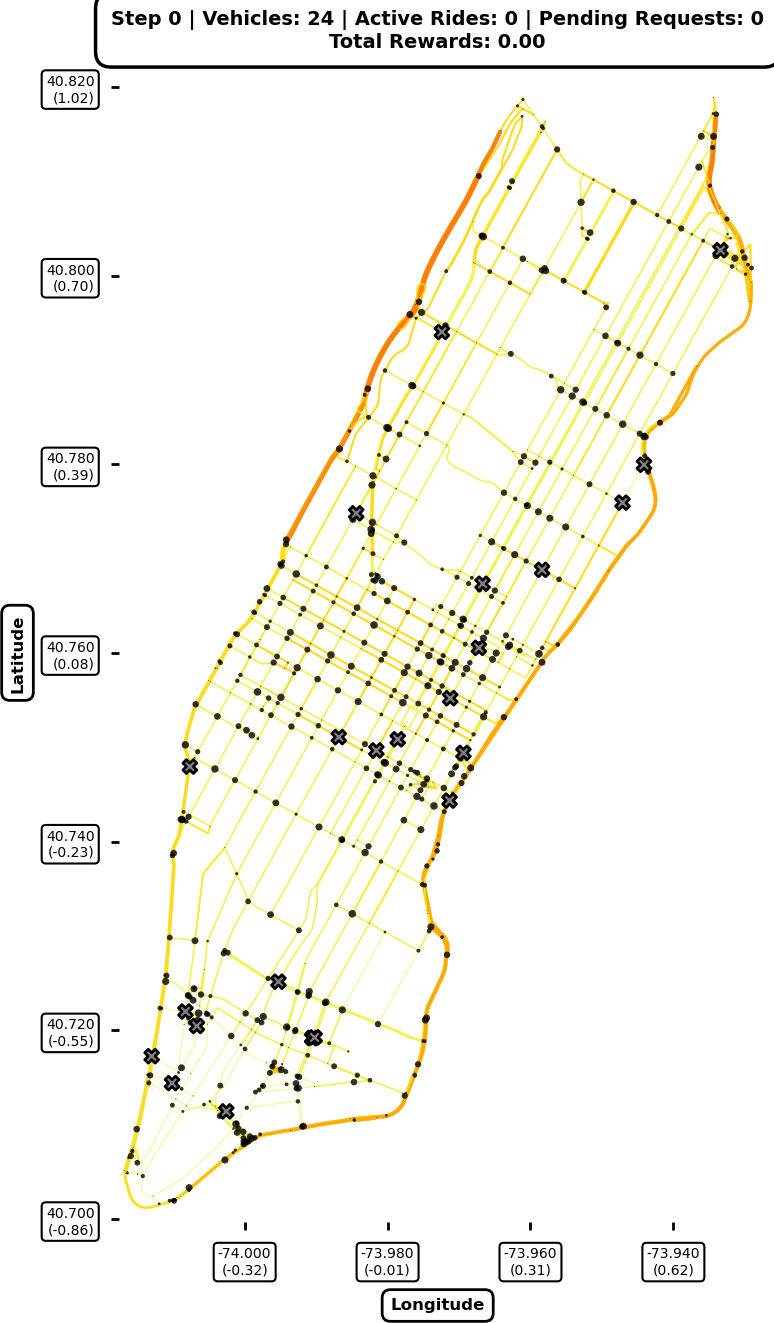

In [65]:
fig

In [66]:
out = env.step(action)

In [67]:
fig, ax = env.render()

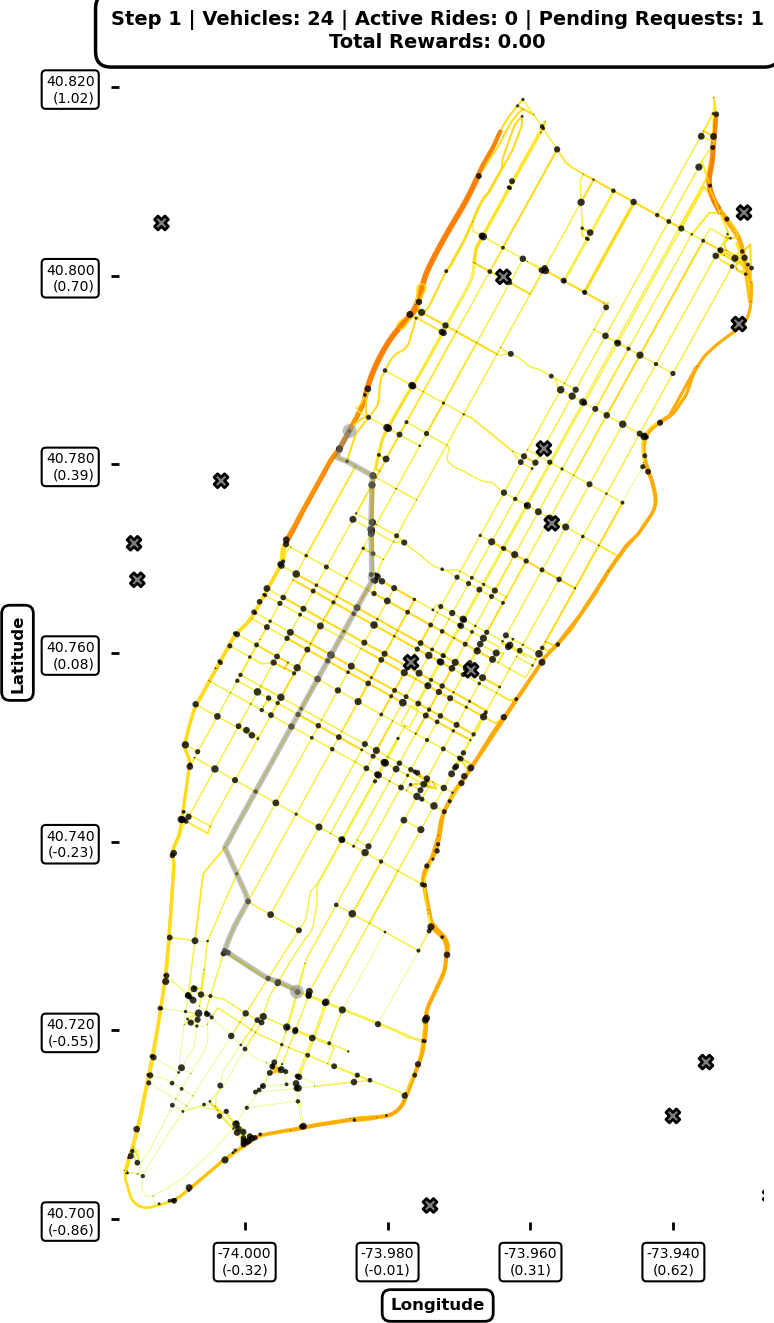

In [68]:
fig